# Evaluating a machine learning model

Three ways to evaluate Scikit-learn models:
1. Estimator `score` method
2. The `scoring` parameter
3. Problem specific metric functions

## 0. Train Models

To avoid making X, y over and over again in classification and regression problem examples ahead. Let's define two functions- one to extract X and y values in Classification dataset (Heart disease) and the other one for regression dataset (House data). 

In [11]:
import pandas as pd
from sklearn.datasets import fetch_california_housing


def get_classification_X_y(data_path="data/heart-disease.csv", target_var="target"):
    df = pd.read_csv(data_path)
    X = df.drop(target_var, axis=1)
    y = df[target_var]
    return X, y


def get_regression_X_y(data_path=None, target_var=None):
    if not data_path:
        return fetch_california_housing(as_frame=True, return_X_y=True)
    elif data_path and target_var:
        return get_classification_X_y(data_path=data_path, target_var=target_var)

### 0.1 Classification Problem

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X, y = get_classification_X_y()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y, test_size=0.2)

clf = RandomForestClassifier()
clf.fit(X_train_clf, y_train_clf)

RandomForestClassifier()

In [13]:
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [14]:
df.shape

(303, 14)

### 0.2 Regression Problem

In [15]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

X, y = get_regression_X_y()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y)

reg = RandomForestRegressor()
reg.fit(X_train_reg, y_train_reg)

RandomForestRegressor()

## 1. Using the `score` method

### 1.1 Classification

Returns the mean accuracy on the given test data and labels.

In [16]:
clf.score(X_test_clf, y_test_clf)

0.8524590163934426

### 1.2 Regression 

Returns the coefficient of determination of the prediction.

![r_squared_error](./img/r_squared_err.png)

In [17]:
reg.score(X_test_reg, y_test_reg)

0.806410393875331

## 2. Evaluating a model using the `scoring` parameter

### 2.1. Apply on Classification Problem

In [18]:
from sklearn.model_selection import cross_val_score, train_test_split

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X, y = get_classification_X_y()

X_train, X_test, y_train, y_test = train_test_split(X, y)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

RandomForestClassifier()

Let's look at the score method first

In [19]:
clf.score(X_test, y_test)

0.8289473684210527

Now look at the cross validation score

In [20]:
cross_val_score(clf, X, y, cv=5)
# cv=5 means 5-fold cross-validation.

array([0.81967213, 0.86885246, 0.81967213, 0.78333333, 0.76666667])

But what and how does it work?

[Here's](https://youtu.be/cdZZyF1GGn4?si=UHcdoOFjkG_EhE5_&t=266) the answer:

![cross-validation](./img/cross-val.png)

## Evaluating a Classificaion Model

1. Accuracy
2. Area under ROC curve
3. Confusion Matrix
4. Classification report

### 1. Accuracy

In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X, y = get_classification_X_y()

clf = RandomForestClassifier()

cross_val_score(clf, X, y)

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

A note: cross_val_score **does not fit** the estimator. See [here](https://stackoverflow.com/questions/42263915/using-sklearn-cross-val-score-and-kfolds-to-fit-and-help-predict-model)

### 2. Area under ROC

It is also known as AUC - Area under ROC curve.

ROC stands for "Receiver Operating Characteristics".

AUC measures the enire two-dimensional area underneath the entire ROC curve from (0, 0) to (1, 1). Kinda like integration.

Okay Let's break it down:

First, let's look at the terminologies -

In our dataset, our classification model is trying to predict two classes either heart disease present or not. In other words, we are predicting two classes it's either False(0) [heart deases absent] or Postive(1) [heart disease present]. Based on all the possible cases in this predictions we can observe the following -

| Observation | Meaning | Description | Result |
|------|---------|-------------|--------|
| TP | True Positive | Predicted 1 and It's actually 1 | Correctly (Truely) predicted 1 |
| FP | False Positive | Predicted 1 but It's acutally 0 | Incorrectly (Falsely) predicted 1 |
| TN | True Negative | Predicted 0 and It's actually 0 | Correctly (Truely) predicted 0 |
| FN | False Negative | Predicted 0 but It's actually 1 | Incorrectly (Falsely) predicted 0 |

Looking at the table above we can also say that:

Total Positive Cases = TP + FN

Total Negative Cases = TN + FP

Now Let's define more terminologies:

**TPR** -> True Positive Rate. Rate of Truely/Correctly predicted 1's. So, TPR defines how many correct postive results (1s') occur among all positive samples. It is a synonym for **Recall**

**FPR** -> False Positive Rate. Rate of Falsely/Incorrectly predited 1's. So, FPR defines how many incorrect positive results occur among all negative samples.

Thus,

$TPR = \frac{TP}{TP + FN}$

$FPR = \frac{FP}{FP + TN}$

Here's a TPR vs. FPR at different classification thresholds. In other words ROC curve (source: [Google](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc))

![TPR-vs-FPR](https://developers.google.com/static/machine-learning/crash-course/images/ROCCurve.svg)


And here's the AUC:

![AUC](https://developers.google.com/static/machine-learning/crash-course/images/AUC.svg)

Let's do some coding now.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score

X, y = get_classification_X_y()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Make predictions with probabiltiy
y_pred_prabilities = clf.predict_proba(X_test)
y_pred_prabilities[:10]

array([[0.51, 0.49],
       [0.17, 0.83],
       [0.51, 0.49],
       [0.72, 0.28],
       [0.43, 0.57],
       [0.12, 0.88],
       [0.3 , 0.7 ],
       [0.97, 0.03],
       [0.15, 0.85],
       [0.4 , 0.6 ]])

Observation: In each row, the first element is the probality of negative class and 2nd elemnet is positvie class.

We will store the positive prablities in a variable.

In [25]:
y_pred_all_postives = y_pred_prabilities[:, 1]

Why? Well, let's look at the doc string of `roc_curve` function:

Parameters:

**`y_true`**: ndarray of shape (n_samples,) True binary labels. If labels are not either {-1, 1} or {0, 1}, then pos_label should be explicitly given.

**`y_score`**: ndarray of shape (n_samples,) Target scores, can either be probability estimates of the positive class, confidence values, or non-thresholded measure of decisions (as returned by "decision_function" on some classifiers).

Thus, because of the *`y_score`* parameter, we have calculated the postive probabilites.


**The `roc_curve` Returns the following:**


***`fpr`*** : ndarray of shape (>2,)
    Increasing false positive rates such that element i is the false
    positive rate of predictions with score >= `thresholds[i]`.

***`tpr`*** : ndarray of shape (>2,)
    Increasing true positive rates such that element `i` is the true
    positive rate of predictions with score >= `thresholds[i]`.

***`thresholds`*** : ndarray of shape = (n_thresholds,)
    Decreasing thresholds on the decision function used to compute
    fpr and tpr. `thresholds[0]` represents no instances being predicted
    and is arbitrarily set to `max(y_score) + 1`.

In [26]:
# calculate fpr, tpr and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_all_postives)

Now that we have obtained the `fpr` and `tpr`. Let's plot a ROC curve. Shall we?

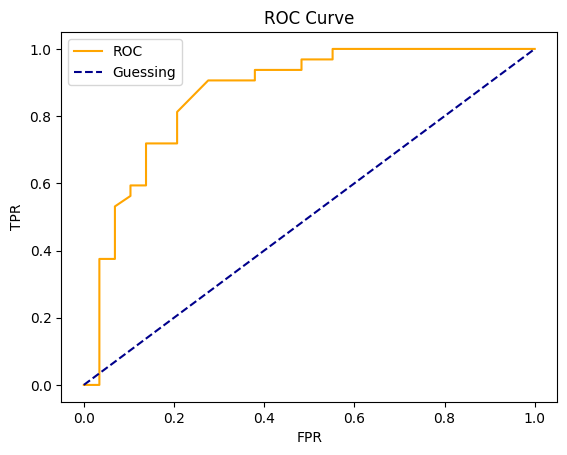

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)

# Plot ROC
ax.plot(fpr, tpr, label="ROC", color="orange")

# Plot line with no predictive power (baseline)
# So, anything above this line is good, and below is bad at prediction
ax.plot([0,1], [0,1], label="Guessing", linestyle="--", color="darkblue")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC Curve")
ax.legend()

plt.show()